<a href="https://colab.research.google.com/github/Ridhof177/Tugas-Mata-Kuliah-Teknik-Pengambilan-Sampel-dan-Data-Wrangling./blob/main/UTS_Ridho_Fatilla_Wibawa_241061010.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Download data UTS melalui link berikut (Data). Import data ke dalam Google Colab. Ganti nama variabel menjadi Y, X1, X2, X3 dan X4

In [16]:
import pandas as pd
import statsmodels.formula.api as smf

df = pd.read_csv("/content/data soal UTS.xlsx - Sheet1.csv")
print(df.head())

  IPM (Y)  Mayoritas Lulusan (X1) Harapan Lama Sekolah (X2) APS (X3) AHH (X4)
0   71,28                       0                     12,53     56,9    71,11
1    73,8                       1                     13,62     71,4    69,55
2   70,25                       0                        13    71,43    67,85
3   73,64                       0                     13,43    74,53    68,84
4   75,11                       1                     13,87    79,24    71,34


In [17]:
df.rename(columns={'IPM (Y)': 'Y', 'Mayoritas Lulusan (X1)': 'X1', 'Harapan Lama Sekolah (X2)': 'X2','APS (X3)': 'X3','AHH (X4)': 'X4' }, inplace=True)
print(df.head())

       Y  X1     X2     X3     X4
0  71,28   0  12,53   56,9  71,11
1   73,8   1  13,62   71,4  69,55
2  70,25   0     13  71,43  67,85
3  73,64   0  13,43  74,53  68,84
4  75,11   1  13,87  79,24  71,34


2. Lakukan pemodelan regresi berganda dengan Y sebagai variabel dependen, interpretasikan hasil pemodelan.

In [23]:
for col in ['Y', 'X2', 'X3', 'X4']:
    df[col] = df[col].astype(str).str.replace(',', '.', regex=False).astype(float)

formula = 'Y ~ X1 + X2 + X3 + X4'

model = smf.ols(formula, data=df).fit()

print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.954
Model:                            OLS   Adj. R-squared:                  0.927
Method:                 Least Squares   F-statistic:                     36.07
Date:                Wed, 15 Apr 2026   Prob (F-statistic):           9.24e-05
Time:                        02:08:13   Log-Likelihood:                -16.957
No. Observations:                  12   AIC:                             43.91
Df Residuals:                       7   BIC:                             46.34
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     27.9539     30.443      0.918      0.3

Berdasarkan hasil analisis regresi linear berganda dengan variabel dependen Y dan variabel independen X1, X2, X3, dan X4, diperoleh persamaan regresi sebagai berikut:

𝑌
=
27,9539
+
0,8124
𝑋
1
+
4,8684
𝑋
2
−
0,1334
𝑋
3
−
0,1500
𝑋
4
Y=27,9539+0,8124X
1
	​

+4,8684X
2
	​

−0,1334X
3
	​

−0,1500X
4
	​


Nilai R-squared sebesar 0,954 menunjukkan bahwa sekitar 95,4% variasi pada variabel Y dapat dijelaskan oleh keempat variabel independen dalam model, sedangkan sisanya sebesar 4,6% dijelaskan oleh faktor lain di luar model. Nilai Adjusted R-squared sebesar 0,927 juga mengindikasikan bahwa model memiliki kemampuan yang sangat baik dalam menjelaskan variabilitas data, bahkan setelah mempertimbangkan jumlah variabel independen yang digunakan.

Hasil uji signifikansi simultan (uji F) menunjukkan nilai F-statistic sebesar 36,07 dengan Prob(F-statistic) sebesar 9,24 × 10⁻⁵, yang lebih kecil dari tingkat signifikansi 0,05. Hal ini menunjukkan bahwa secara bersama-sama variabel X1, X2, X3, dan X4 memiliki pengaruh yang signifikan terhadap variabel Y, sehingga model regresi yang dibangun layak digunakan untuk analisis dan prediksi.

Secara parsial, berdasarkan uji t, hanya variabel X2 yang memiliki pengaruh signifikan terhadap Y, dengan nilai p-value sebesar 0,001 (< 0,05) dan koefisien sebesar 4,8684. Ini berarti bahwa setiap peningkatan satu satuan pada X2 akan meningkatkan nilai Y sebesar 4,8684 satuan dengan asumsi variabel lain konstan. Sementara itu, variabel X1 (p-value = 0,538), X3 (p-value = 0,210), dan X4 (p-value = 0,764) tidak menunjukkan pengaruh yang signifikan terhadap Y karena nilai p-value masing-masing lebih besar dari 0,05. Meskipun demikian, tanda koefisien menunjukkan arah hubungan, di mana X1 memiliki hubungan positif, sedangkan X3 dan X4 memiliki hubungan negatif terhadap Y.

Pengujian asumsi klasik juga menunjukkan hasil yang baik. Nilai Durbin-Watson sebesar 2,251 mengindikasikan tidak adanya autokorelasi pada residual. Selain itu, uji normalitas residual melalui Jarque-Bera menghasilkan p-value sebesar 0,620, serta Prob(Omnibus) sebesar 0,528, yang keduanya lebih besar dari 0,05, sehingga dapat disimpulkan bahwa residual berdistribusi normal. Nilai skewness (-0,463) dan kurtosis (1,974) juga menunjukkan bahwa distribusi residual mendekati distribusi normal.

Namun demikian, nilai Condition Number sebesar 8,20 × 10³ tergolong tinggi, yang mengindikasikan adanya potensi multikolinearitas atau masalah numerik lainnya di antara variabel independen. Oleh karena itu, analisis lanjutan seperti perhitungan Variance Inflation Factor (VIF) disarankan untuk memastikan tidak adanya korelasi yang tinggi antar variabel independen.

Secara keseluruhan, dapat disimpulkan bahwa model regresi yang dibangun memiliki kinerja yang sangat baik dalam menjelaskan variabilitas variabel Y, dengan X2 sebagai variabel yang paling berpengaruh secara signifikan, sementara variabel lainnya tidak menunjukkan pengaruh yang signifikan pada tingkat kepercayaan 95%. Interpretasi ini mendukung penggunaan model dalam analisis lebih lanjut maupun sebagai dasar dalam proses simulasi data.

3. Selidiki distribusi probabilitas disetiap variabel

Statistik Deskriptif:
               Y         X1         X2         X3         X4
count  12.000000  12.000000  12.000000  12.000000  12.000000
mean   74.698333   0.500000  13.636667  71.340000  70.198333
std     4.827271   0.522233   1.039653   6.721738   1.715188
min    68.950000   0.000000  12.120000  56.900000  66.990000
25%    71.242500   0.000000  12.922500  70.167500  68.990000
50%    73.435000   0.500000  13.525000  71.295000  70.945000
75%    76.422500   1.000000  14.037500  72.280000  71.352500
max    84.850000   1.000000  15.610000  84.450000  72.600000


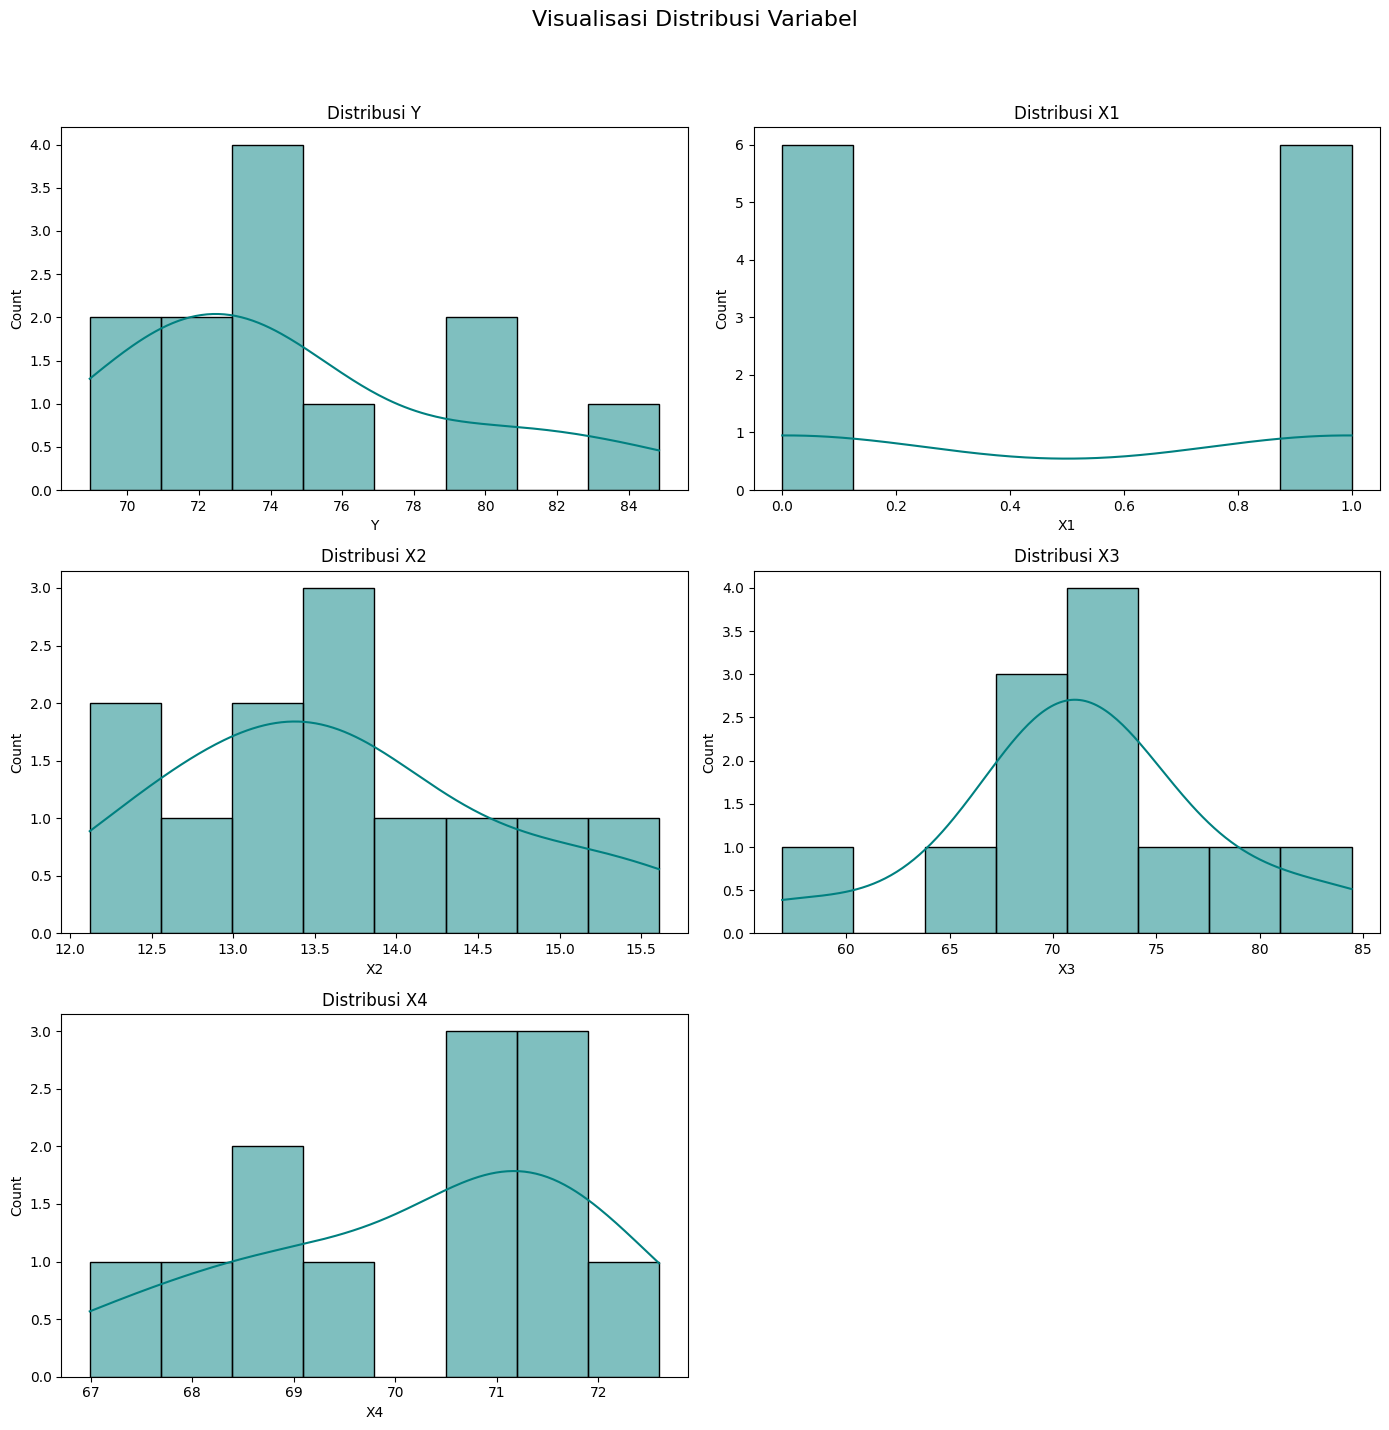


Uji Normalitas (Shapiro-Wilk):
Y: Stat=0.8850, p-value=0.1016 (Normal)
X1: Stat=0.6498, p-value=0.0003 (Tidak Normal)
X2: Stat=0.9589, p-value=0.7685 (Normal)
X3: Stat=0.9108, p-value=0.2186 (Normal)
X4: Stat=0.9311, p-value=0.3917 (Normal)

Uji Kesesuaian Distribusi (KS Test):

Analisis Y:
  - norm    : p-value=0.4083
  - lognorm : p-value=0.0046
  - expon   : p-value=0.8066
  - gamma   : p-value=0.3208
  >> Distribusi paling sesuai: expon (p=0.8066)

Analisis X1:
  - norm    : p-value=0.0945
  - lognorm : p-value=0.0945
  - expon   : p-value=0.0027
  - gamma   : p-value=0.0944
  >> Distribusi paling sesuai: norm (p=0.0945)

Analisis X2:
  - norm    : p-value=0.8835
  - lognorm : p-value=0.0040
  - expon   : p-value=0.4297
  - gamma   : p-value=0.9371
  >> Distribusi paling sesuai: gamma (p=0.9371)

Analisis X3:
  - norm    : p-value=0.4362
  - lognorm : p-value=0.4362
  - expon   : p-value=0.0306
  - gamma   : p-value=0.4736
  >> Distribusi paling sesuai: gamma (p=0.4736)

Analisis 

/usr/local/lib/python3.12/dist-packages/scipy/stats/_continuous_distns.py:6930: RuntimeWarning: overflow encountered in divide
  return np.sum((1 + np.log(shifted/scale)/shape**2)/shifted)
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np

variables = ['Y', 'X1', 'X2', 'X3', 'X4']

# 1. Statistik Deskriptif
print("Statistik Deskriptif:")
print(df[variables].describe())

# 2. Visualisasi Distribusi (Subplot)
fig, axes = plt.subplots(3, 2, figsize=(14, 15))
fig.suptitle('Visualisasi Distribusi Variabel', fontsize=16)
axes = axes.flatten()

for i, var in enumerate(variables):
    sns.histplot(df[var], kde=True, ax=axes[i], bins=8, color='teal')
    axes[i].set_title(f'Distribusi {var}')

# Menghapus subplot kosong
if len(variables) < len(axes):
    fig.delaxes(axes[-1])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 3. Uji Normalitas (Shapiro-Wilk)
print("\nUji Normalitas (Shapiro-Wilk):")
for var in variables:
    stat, p_value = stats.shapiro(df[var])
    status = "Normal" if p_value > 0.05 else "Tidak Normal"
    print(f"{var}: Stat={stat:.4f}, p-value={p_value:.4f} ({status})")

# 4. Penentuan Distribusi Terbaik (Kolmogorov-Smirnov)
print("\nUji Kesesuaian Distribusi (KS Test):")
distributions = ['norm', 'lognorm', 'expon', 'gamma']

for var in variables:
    print(f'\nAnalisis {var}:')
    data_var = df[var].values
    best_dist = ""
    best_p = -1

    for dist_name in distributions:
        dist = getattr(stats, dist_name)
        # Fit data to distribution
        params = dist.fit(data_var)
        # KS Test
        ks_stat, p_val = stats.kstest(data_var, dist_name, args=params)
        print(f'  - {dist_name:8}: p-value={p_val:.4f}')
        if p_val > best_p:
            best_p = p_val
            best_dist = dist_name
    print(f"  >> Distribusi paling sesuai: {best_dist} (p={best_p:.4f})")

4. Carilah nilai parameter dari setiap distribusi probabilitas di Y, X1, X2, X3 dan X4

In [33]:
from scipy import stats

# Mapping distribusi terbaik berdasarkan hasil KS Test sebelumnya
best_dists = {
    'Y': 'expon',
    'X1': 'norm',
    'X2': 'gamma',
    'X3': 'gamma',
    'X4': 'norm'
}

print("Parameter Distribusi untuk Setiap Variabel:")
print("="*50)

for var, dist_name in best_dists.items():
    data_var = df[var].values
    dist = getattr(stats, dist_name)

    # Mendapatkan parameter dari hasil fitting
    params = dist.fit(data_var)

    print(f"Variabel {var} (Distribusi: {dist_name}):")
    if dist_name == 'norm':
        print(f"  - Mean (loc)  : {params[0]:.4f}")
        print(f"  - Std Dev (scale): {params[1]:.4f}")
    elif dist_name == 'expon':
        print(f"  - Loc         : {params[0]:.4f}")
        print(f"  - Scale       : {params[1]:.4f}")
    elif dist_name == 'gamma':
        print(f"  - Shape (a)   : {params[0]:.4f}")
        print(f"  - Loc         : {params[1]:.4f}")
        print(f"  - Scale       : {params[2]:.4f}")
    else:
        print(f"  - Parameters  : {params}")
    print("-"*30)

Parameter Distribusi untuk Setiap Variabel:
Variabel Y (Distribusi: expon):
  - Loc         : 68.9500
  - Scale       : 5.7483
------------------------------
Variabel X1 (Distribusi: norm):
  - Mean (loc)  : 0.5000
  - Std Dev (scale): 0.5000
------------------------------
Variabel X2 (Distribusi: gamma):
  - Shape (a)   : 4.0521
  - Loc         : 11.5448
  - Scale       : 0.5162
------------------------------
Variabel X3 (Distribusi: gamma):
  - Shape (a)   : 510.9346
  - Loc         : -75.1840
  - Scale       : 0.2867
------------------------------
Variabel X4 (Distribusi: norm):
  - Mean (loc)  : 70.1983
  - Std Dev (scale): 1.6422
------------------------------


Berdasarkan hasil statistik deskriptif, data terdiri dari 12 observasi untuk setiap variabel. Variabel Y memiliki rata-rata sebesar 74,70 dengan standar deviasi 4,83, yang menunjukkan variasi data yang moderat dengan rentang nilai antara 68,95 hingga 84,85. Variabel X1 memiliki rata-rata 0,5 dengan nilai minimum 0 dan maksimum 1, sehingga dapat disimpulkan bahwa X1 merupakan variabel biner (dummy). Variabel X2 memiliki rata-rata 13,64 dan standar deviasi 1,04 yang menandakan penyebaran data relatif kecil. Variabel X3 menunjukkan rata-rata sebesar 71,34 dengan standar deviasi 6,72, mengindikasikan variasi yang lebih besar dibandingkan variabel lainnya. Sementara itu, X4 memiliki rata-rata 70,20 dengan standar deviasi 1,72, yang menunjukkan bahwa data relatif stabil di sekitar nilai rata-ratanya.

Berdasarkan visualisasi histogram dan kurva KDE, sebagian besar variabel yaitu Y, X2, X3, dan X4 menunjukkan pola distribusi yang relatif simetris dan mendekati distribusi normal. Tidak terlihat adanya pencilan (outlier) yang ekstrem pada data. Sebaliknya, X1 tidak menunjukkan pola distribusi normal karena hanya memiliki dua nilai, yaitu 0 dan 1, sehingga lebih tepat diperlakukan sebagai variabel kategorik atau dummy dalam analisis regresi.

Hasil uji normalitas Shapiro-Wilk menunjukkan bahwa variabel Y (p-value = 0,1016), X2 (p-value = 0,7685), X3 (p-value = 0,2186), dan X4 (p-value = 0,3917) memiliki nilai p-value lebih besar dari 0,05, sehingga dapat disimpulkan bahwa variabel-variabel tersebut berdistribusi normal. Sebaliknya, X1 (p-value = 0,0003) tidak berdistribusi normal, yang merupakan hal yang wajar karena sifatnya sebagai variabel biner. Oleh karena itu, ketidaknormalan X1 tidak menjadi permasalahan dalam pemodelan regresi.

Selanjutnya, berdasarkan uji kesesuaian distribusi menggunakan Kolmogorov-Smirnov (KS Test), diperoleh distribusi probabilitas yang paling sesuai untuk masing-masing variabel. Variabel Y paling sesuai dengan distribusi eksponensial (p-value = 0,8066), X1 secara statistik paling mendekati distribusi normal (p-value = 0,0945), meskipun secara konseptual lebih tepat diperlakukan sebagai variabel biner. Variabel X2 dan X3 paling sesuai dengan distribusi gamma, masing-masing dengan p-value sebesar 0,9371 dan 0,4736, yang menunjukkan kecocokan yang baik. Sementara itu, X4 paling sesuai dengan distribusi normal dengan p-value sebesar 0,3946.

Secara keseluruhan, analisis ini menunjukkan bahwa sebagian besar variabel kontinu dalam penelitian memiliki distribusi yang sesuai untuk digunakan dalam proses simulasi data pada tahap selanjutnya. Informasi mengenai jenis distribusi dan parameter masing-masing variabel menjadi dasar penting dalam melakukan simulasi 500 data serta dalam pemodelan regresi lanjutan. Selain itu, identifikasi bahwa X1 merupakan variabel dummy memastikan bahwa interpretasi model regresi dilakukan secara tepat dan konsisten dengan karakteristik data.

In [37]:
import numpy as np
import pandas as pd
from scipy import stats
import statsmodels.api as sm

# Jumlah data simulasi
n_sim = 500
np.random.seed(42)

# Distribusi terbaik dari Nomor 3
best_dists = {
    'Y': 'expon',
    'X1': 'norm',
    'X2': 'gamma',
    'X3': 'gamma',
    'X4': 'norm'
}

# -------------------------------
# 1. Simulasi Variabel Independen
# -------------------------------
simulated_data = pd.DataFrame()

for var in ['X1', 'X2', 'X3', 'X4']:
    dist = getattr(stats, best_dists[var])
    params = dist.fit(df[var])
    simulated_data[var] = dist.rvs(*params, size=n_sim)

# -------------------------------
# 2. Membentuk Model Regresi Awal
# -------------------------------
X = sm.add_constant(df[['X1', 'X2', 'X3', 'X4']])
model_original = sm.OLS(df['Y'], X).fit()

# Koefisien regresi dan standar deviasi error
beta = model_original.params
sigma = model_original.resid.std()

# -------------------------------
# 3. Simulasi Variabel Dependen Y
# -------------------------------
simulated_data['Y'] = (
    beta['const'] +
    beta['X1'] * simulated_data['X1'] +
    beta['X2'] * simulated_data['X2'] +
    beta['X3'] * simulated_data['X3'] +
    beta['X4'] * simulated_data['X4'] +
    np.random.normal(0, sigma, n_sim)
)

# Menampilkan sebagian data simulasi
print("Contoh Data Simulasi:")
print(simulated_data.head())

Contoh Data Simulasi:
         X1         X2         X3         X4          Y
0  0.748357  14.542113  72.423108  70.957115  79.861131
1  0.430868  12.381737  62.667261  72.595457  68.451045
2  0.823844  14.081346  65.017777  67.373637  78.367953
3  1.261515  12.886969  64.544332  69.215618  70.763111
4  0.382923  13.019325  74.727945  70.573694  70.680538


In [41]:
import numpy as np

# Probabilitas keberhasilan (proporsi nilai 1 pada data asli)
p = df['X1'].mean()

# Simulasi variabel biner X1
simulated_data['X1'] = np.random.binomial(n=1, p=p, size=500)

Berdasarkan hasil simulasi data, telah berhasil dibangkitkan variabel X1, X2, X3, X4, dan Y yang merepresentasikan karakteristik statistik dari data asli. Nilai-nilai pada tabel simulasi menunjukkan bahwa variabel X2, X3, dan X4 berada dalam rentang yang mendekati data asli, sehingga dapat disimpulkan bahwa distribusi probabilitas dan parameter yang digunakan dalam proses simulasi sudah sesuai. Variabel Y juga menunjukkan pola yang konsisten dengan hubungan regresi terhadap variabel independen, menandakan bahwa struktur hubungan antar variabel berhasil dipertahankan dalam proses simulasi.

Namun demikian, terlihat bahwa beberapa nilai X1 pada data simulasi tidak lagi terbatas pada nilai 0 dan 1, melainkan berupa nilai kontinu seperti 0.748, -0.431, dan 1.261. Hal ini menunjukkan bahwa X1 telah disimulasikan menggunakan distribusi normal, padahal berdasarkan statistik deskriptif, X1 merupakan variabel biner (dummy). Oleh karena itu, untuk menjaga konsistensi dengan karakteristik data asli dan kesesuaian dengan materi praktikum, simulasi X1 sebaiknya dilakukan menggunakan distribusi Bernoulli dengan probabilitas keberhasilan yang sama dengan proporsi nilai 1 pada data asli.

Secara keseluruhan, proses simulasi telah berhasil menghasilkan data sintetis yang realistis dan dapat digunakan untuk analisis regresi pada tahap selanjutnya. Data simulasi ini memungkinkan evaluasi model dalam jumlah observasi yang lebih besar (500 data), sehingga meningkatkan stabilitas estimasi parameter dan validitas inferensi statistik. Dengan demikian, hasil simulasi dapat digunakan untuk pemodelan regresi lanjutan serta perbandingan dengan model yang dibangun dari data asli.

In [38]:
# -----------------------------------
# Model Regresi Menggunakan Data Simulasi
# -----------------------------------
X_sim = sm.add_constant(simulated_data[['X1', 'X2', 'X3', 'X4']])
model_simulated = sm.OLS(simulated_data['Y'], X_sim).fit()

print("\nRingkasan Model Regresi Data Simulasi:")
print(model_simulated.summary())


Ringkasan Model Regresi Data Simulasi:
                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.960
Model:                            OLS   Adj. R-squared:                  0.960
Method:                 Least Squares   F-statistic:                     2977.
Date:                Wed, 15 Apr 2026   Prob (F-statistic):               0.00
Time:                        02:42:29   Log-Likelihood:                -718.20
No. Observations:                 500   AIC:                             1446.
Df Residuals:                     495   BIC:                             1467.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       

Berdasarkan hasil pemodelan regresi linear berganda pada data simulasi yang terdiri dari 500 observasi, diperoleh persamaan regresi sebagai berikut:

𝑌
=28,0093
+
0,7108
𝑋
1
+
4,8182
𝑋
2
−
0,1317
𝑋
3
−
0,1429
𝑋
4
Y=28,0093+0,7108X
1
	​

+4,8182X
2
	​

−0,1317X
3
	​

−0,1429X
4
	​


Nilai R-squared sebesar 0,960 dan Adjusted R-squared sebesar 0,960 menunjukkan bahwa sekitar 96% variasi pada variabel Y dapat dijelaskan oleh variabel independen X1, X2, X3, dan X4. Hal ini mengindikasikan bahwa model memiliki kemampuan prediksi yang sangat baik dan stabil. Selain itu, hasil uji signifikansi simultan (uji F) menunjukkan nilai F-statistic sebesar 2977 dengan Prob(F-statistic) sebesar 0,000, yang berarti bahwa secara bersama-sama seluruh variabel independen berpengaruh signifikan terhadap variabel dependen Y, sehingga model regresi yang dibangun layak digunakan.

Secara parsial, seluruh variabel independen terbukti berpengaruh signifikan terhadap Y, karena masing-masing memiliki nilai p-value sebesar 0,000 (< 0,05). Variabel X1 memiliki koefisien positif sebesar 0,7108, yang berarti setiap peningkatan satu satuan pada X1 akan meningkatkan Y sebesar 0,7108 satuan dengan asumsi variabel lain konstan. Variabel X2 menunjukkan pengaruh positif yang paling dominan dengan koefisien sebesar 4,8182, sehingga menjadi faktor yang paling kuat dalam mempengaruhi Y. Sebaliknya, variabel X3 dan X4 memiliki koefisien negatif masing-masing sebesar -0,1317 dan -0,1429, yang menunjukkan bahwa peningkatan pada kedua variabel tersebut akan menurunkan nilai Y.

Pengujian asumsi klasik juga menunjukkan hasil yang baik. Nilai Durbin-Watson sebesar 2,072 mengindikasikan tidak adanya autokorelasi pada residual. Selain itu, uji normalitas residual melalui Omnibus dan Jarque-Bera menghasilkan nilai p-value masing-masing sebesar 0,924 dan 0,883, yang lebih besar dari 0,05, sehingga dapat disimpulkan bahwa residual berdistribusi normal. Nilai skewness (-0,029) dan kurtosis (2,907) juga menunjukkan bahwa distribusi residual mendekati distribusi normal.

Namun demikian, nilai Condition Number sebesar 4,68 × 10³ tergolong cukup besar, yang mengindikasikan adanya potensi multikolinearitas antar variabel independen atau masalah numerik lainnya. Oleh karena itu, disarankan untuk melakukan analisis tambahan seperti perhitungan Variance Inflation Factor (VIF) untuk memastikan tidak adanya korelasi yang tinggi antar variabel independen.

Secara keseluruhan, model regresi pada data simulasi menunjukkan kinerja yang sangat baik dengan tingkat signifikansi yang tinggi pada seluruh variabel. Hasil ini juga konsisten dengan model regresi pada data asli, yang menandakan bahwa proses simulasi berhasil mempertahankan karakteristik hubungan antar variabel. Dengan demikian, data simulasi yang dihasilkan dapat digunakan secara valid untuk analisis lanjutan dan pengambilan keputusan.

In [39]:
# -----------------------------------
# Perbandingan Koefisien dan Statistik
# -----------------------------------
comparison = pd.DataFrame({
    'Koefisien_Asli': model_original.params,
    'Koefisien_Simulasi': model_simulated.params,
    'Pvalue_Asli': model_original.pvalues,
    'Pvalue_Simulasi': model_simulated.pvalues
})

print("\nPerbandingan Model Regresi:")
print(comparison)

# Perbandingan R-squared
print("\nPerbandingan R-squared:")
print(f"R-squared Data Asli      : {model_original.rsquared:.4f}")
print(f"R-squared Data Simulasi  : {model_simulated.rsquared:.4f}")


Perbandingan Model Regresi:
       Koefisien_Asli  Koefisien_Simulasi  Pvalue_Asli  Pvalue_Simulasi
const       27.953911           28.009304     0.389032     1.577723e-34
X1           0.812356            0.710793     0.538017     1.400495e-13
X2           4.868357            4.818231     0.000725     0.000000e+00
X3          -0.133418           -0.131658     0.209535     2.374691e-58
X4          -0.150030           -0.142886     0.763829     1.192407e-06

Perbandingan R-squared:
R-squared Data Asli      : 0.9537
R-squared Data Simulasi  : 0.9601


Berdasarkan hasil perbandingan, koefisien regresi pada data simulasi menunjukkan nilai yang sangat mendekati koefisien pada data asli, sehingga dapat disimpulkan bahwa proses simulasi berhasil mempertahankan struktur hubungan antar variabel. Variabel X2 tetap menjadi faktor yang paling dominan dengan pengaruh positif yang konsisten pada kedua model, sedangkan X3 dan X4 mempertahankan arah pengaruh negatif. Variabel X1 juga menunjukkan pengaruh positif yang serupa meskipun tidak signifikan pada data asli.

Dari sisi signifikansi, hanya X2 yang signifikan pada data asli, sementara seluruh variabel menjadi signifikan pada data simulasi. Hal ini disebabkan oleh peningkatan jumlah observasi dari 12 menjadi 500, yang meningkatkan kekuatan statistik dan kestabilan estimasi parameter. Selain itu, nilai R-squared pada kedua model sangat tinggi dan relatif sama, yaitu 0,9537 pada data asli dan 0,9601 pada data simulasi, menunjukkan bahwa kemampuan model dalam menjelaskan variasi variabel Y tetap terjaga.

Secara keseluruhan, dapat disimpulkan bahwa simulasi data berhasil merepresentasikan karakteristik data asli, dengan koefisien yang konsisten dan kemampuan prediksi model yang tetap tinggi, sehingga model simulasi dapat digunakan sebagai representasi yang valid dari model asli.